<table>
    <tr>
      <td>Minería de datos y Paradigma BigData (<b>MIN</b>)- Facultad de Informática - UCM
      </td>
      <td>
      <img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg"  width=50/>
      </td>
     </tr>
</table>




### Práctica 5: Preprocesamiento Fútbol

Pablo C. Cañizares


Has recibido una llamada de una conocida compañía de fútbol electónico, te necesitan como analista de datos para tomar decisiones. 
Los campos del *dataset* a analizar son los siguientes:

| Variable       | Descripción (castellano)                                                                            | Ejemplo               |
| -------------- | --------------------------------------------------------------------------------------------------- | --------------------- |
| **Ratings**    | Puntuación global de la carta (0 – 99).                                                             | 92                    |
| **Position**   | Posición principal del jugador en el campo (por ej., POR, DC, MC).                                  | DC                    |
| **Version**    | Tipo o edición de la carta (Oro, TOTW, TOTY, Flashback, etc.).                                      | TOTY                  |
| **Price**         | Precio en el mercado de PlayStation; **0** indica que no está disponible.                           | 550 000               |
| **SKI**        | Estrellas de filigranas (0 – 5).                                                                    | 5                     |
| **WF**         | Estrellas de pierna mala (0 – 5).                                                                   | 4                     |
| **WR**         | Ritmo de trabajo ataque/defensa; cada valor puede ser *bajo*, *medio* o *alto* (ej.: alto / medio). | alto / medio          |
| **PAC**        | Ritmo (velocidad).                                                                                  | 93                    |
| **SHO**        | Disparo (potencia y precisión de tiro).                                                             | 89                    |
| **PAS**        | Pase.                                                                                               | 91                    |
| **DRI**        | Regate.                                                                                             | 94                    |
| **DEF**        | Defensa.                                                                                            | 45                    |
| **PHY**        | Fuerza física.                                                                                      | 78                    |
| **Body**       | Altura en cm y pies + tipo de complexión del jugador + peso.            | 182 cm / 6'0" — Única |
| **Popularity** | Índice de popularidad de uso entre la comunidad.                                                    | 87                    |
| **BS**         | Suma de estadísticas base (*Base Stats*).                                                           | 495                   |
| **IGS**        | Suma de estadísticas “en partido” (*In-Game Stats*).                                                | 2 300                 |



Antes de arrancar la experiencia, vamos a instalar módulos nuevos

In [2]:
modules = ["numpy", "pandas", "matplotlib", "scikit-learn", "beautifulsoup4", "pprint", "seaborn"]

import sys
import os.path
from subprocess import check_call
import importlib
import os

def instala(modules):
    print("Instalando módulos")
    for m in modules:
        # para el import quitamos [...] y ==...
        p = m.find("[")
        mi = m if p==-1 else m[:p]
        p = mi.find("==")
        mi = mi if p==-1 else mi[:p]
        torch_loader = importlib.util.find_spec(mi)
        if torch_loader is not None:
            print(m," encontrado")
        else:
            print(m," No encontrado, instalando...",end="")  
            try:        
                r = check_call([sys.executable, "-m", "pip", "install", "--user", m])
                print("¡hecho!")
            except:
                print("¡Problema al instalar ",m,"! ¿seguro que el módulo existe?",sep="")

    print("¡Terminado!")

instala(modules)  

Instalando módulos
numpy  encontrado
pandas  encontrado
matplotlib  encontrado
scikit-learn  No encontrado, instalando...¡hecho!
beautifulsoup4  No encontrado, instalando...¡hecho!
pprint  encontrado
seaborn  encontrado
¡Terminado!


---------------------

## Iniciamos cargando los dataframes

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns

original = pd.read_csv("analista_futbol.csv") 
df_main = original.copy()

df_main.head()

,Name,RAT,POS,VER,Price,SKI,WF,WR,PAC,SHO,PAS,DRI,DEF,PHY,Body,Popularity,BS,IGS
0,Pelé,99,"LW RM,LM,RW",Shapeshifters ICON Explosive,2.88M,5,5,H \ M,96,97,94,99,61,78,"173cm | 5'8"" Unique (70kg)",3080,525,2557
1,Kevin De Bruyne,99,CM CAM,Level Up Obj Controlled,0,5,5,H \ H,88,95,99,97,91,99,"181cm | 5'11"" Unique (70kg)",1048,569,2743
2,Cristiano Ronaldo,99,"ST CF,LW",Futties Premium Controlled,9.8M,5,5,H \ L,97,99,93,97,41,88,"187cm | 6'2"" CR7 (83kg)",4143,515,2499
3,Lionel Messi,99,"ST RM,RW",Futties Premium Controlled,5.95M,5,5,H \ L,95,98,99,99,41,81,"169cm | 5'7"" Messi (67kg)",2757,513,2506
4,Neymar Jr,99,"CAM LM,LW",Futties Explosive,0,5,5,H \ M,99,96,95,99,50,78,"175cm | 5'9"" Neymar (68kg)",1335,517,2531


---

### **Ejercicio 1** (3 puntos) 
Implementa una función *modifica* que dado un dataframe (ya cargado), realice operaciones de manejo de columnnas y variables.
Realiza las siguientes operaciones: 

- Haz una función que convierta la columna Body en dos columnas: *Weigth* y *Height*, en centímetros y kilogramos respectivamente. Las columnas deben ser del tipo numerico. Al terminar, asegúrate de eliminar la columna *Body*.
- Haz una función que gestione la columna *POS*, y se quede únicamente el primer resultado de la lista. Es decir, si inicialmente tiene *LW RM,LM,R*, únicamente se debe quedar con *LW*.  Al terminar, asegúrate de eliminar la columna *POS*.
- Haz una función que gestione la columna *WR*, y genere dos columnas: *AttackWorkRate* y *DefenseWorkRate*, los valores se obtienen de los operandos contenidos en la columna. La columna tiene valores en formato *X\Y* (ej. 'H \ M'), el primero sería *AttackWorkRate* y el segundo *DefenseWorkRate*. Elimina la columna *WR*.

Recordatorio: Para aplicar una función a un dataframe se utiliza [`apply`](https://pandas.pydata.org/pandas-docs/dev/reference/api/pandas.DataFrame.apply.html)

In [83]:
#solución            
import pandas as pd

def modifica(df):
    #...
    df_ret=df.copy()
    serie=df['Body'].tolist()
    lista_cm=[]
    lista_kg=[]
    for s in serie:
        s = s.replace('|','')
        s = s.replace('(','')
        s = s.replace(')','')
        a=s.split(" ")
        cm = list(filter(lambda x: "cm" in x, a))
        if not cm:
            cm.append(None)
        else:
            cm[0]=cm[0].replace('cm','')
            cm[0] = int(cm[0])
        kg = list(filter(lambda x: "kg" in x, a))
        if not kg:
            kg.append(None)
        else:
            kg[0]=kg[0].replace('kg','')
            cm[0] = int(cm[0])
        lista_cm.append(cm[0])
        lista_kg.append(kg[0])
        

    df_ret = df_ret.drop(columns = ['Body'])
    df_ret['Height'] = lista_cm
    df_ret['Weigth'] = lista_kg
    return df_ret


In [85]:
#Para probarlo ...
df_mod = modifica(df_main)
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22022 entries, 0 to 22021
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        22022 non-null  object
 1   RAT         22022 non-null  int64 
 2   POS         22022 non-null  object
 3   VER         22022 non-null  object
 4   Price       22022 non-null  object
 5   SKI         22022 non-null  int64 
 6   WF          22022 non-null  int64 
 7   WR          22022 non-null  object
 8   PAC         22022 non-null  int64 
 9   SHO         22022 non-null  int64 
 10  PAS         22022 non-null  int64 
 11  DRI         22022 non-null  int64 
 12  DEF         22022 non-null  int64 
 13  PHY         22022 non-null  int64 
 14  Popularity  22022 non-null  int64 
 15  BS          22022 non-null  int64 
 16  IGS         22022 non-null  int64 
 17  Height      22022 non-null  int64 
 18  Weigth      21857 non-null  object
dtypes: int64(13), object(6)
memory usage: 3.2+ MB


#### **Ejercicio** 2 (1 punto) - Implementa una función *matriz_correlacion*.
Dado un dataframe (ya cargado) muestra su matriz de correlación en modo gráfico.

In [90]:
def matriz_correlacion(df, name):
    #solución
    corr_df = df.drop(columns = ['Name', 'POS', 'VER', 'Price', 'WR'])
    corr_df = corr_df.corr(method="pearson")

    sns.heatmap(corr_df, annot=True)
    plt.show()

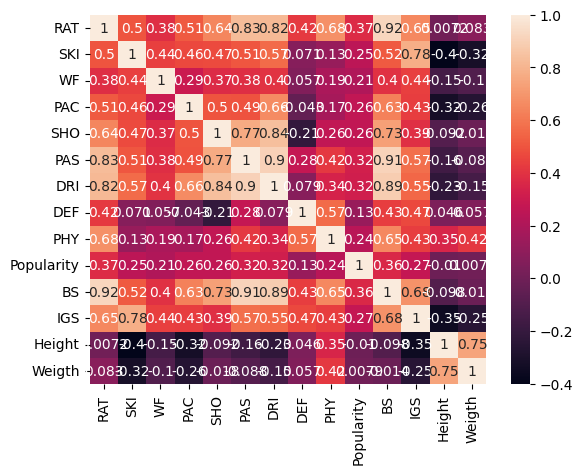

In [91]:
#Para probarlo ...
matriz_correlacion(df_mod, "FIFA")

¿Qué variables consideras que son redundantes? ¿Se podrían eliminar?

---
### **Ejercicio** 3 - (3 puntos). Implementa una función *transforma_categóricas*.
Dado un dataframe (ya cargado) transforma las variables categoricas del dataframe (puedes descartar 'Name'), tal como hemos visto en clase. Finalmente el dataframe debe ser retornado al usuario. 

In [69]:
#solución
def transforma_categoricas(df):
    #...
    return df_catRet

Justifica el método que has utilizado para realizar la transformación y las variables transformadas.

In [70]:
#Para probar
df_trans = transforma_categoricas(df_mod);
df_trans.head()

,Name,RAT,VER,Price,SKI,WF,PAC,SHO,PAS,DRI,...,Pos_GK,Pos_LB,Pos_LM,Pos_LW,Pos_LWB,Pos_RB,Pos_RM,Pos_RW,Pos_RWB,Pos_ST
0,Pelé,99,Shapeshifters ICON Explosive,2.88M,5,5,96,97,94,99,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Kevin De Bruyne,99,Level Up Obj Controlled,0,5,5,88,95,99,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Cristiano Ronaldo,99,Futties Premium Controlled,9.8M,5,5,97,99,93,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Lionel Messi,99,Futties Premium Controlled,5.95M,5,5,95,98,99,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Neymar Jr,99,Futties Explosive,0,5,5,99,96,95,99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

### **Ejercicio 4** (1 punto). Central dominante. 

Análisis comparativo. Una vez preprocesado el dataset, será necesario implementar las consultas necesarias para marcar la diferencia en el mercado de fichajes.

Queremos encontrar al defensa central más dominante que cumpla las siguientes características: 
 - Juega en la posición *CB*
 - PHY >= 85
 - DEF >= 85
 - Altura >= 185
 - Ratings >= 87

Además de cumplir las características anteriores, se quiere medir con el índice de fuerza-defensa-popularidad. El cual se calcula sumando esas tres características del jugador. Haz una lista de los 3 mejores defensas centrales (invoca en un dataframe el método [**sort_values**](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)) que reúnan todas estas características y ordenalos por el índice descrito.

In [95]:
#Solución
#print(df_mod['Pos'].unique())
# Filtro de defensas centrales muy físicos
serie_pos = df_mod.POS
lista_pos = serie_pos[serie_pos == 'CB'].index.tolist()

serie_phy = df_mod.PHY
lista_phy = serie_phy[serie_phy >= 85].index.tolist()

serie_def = df_mod.DEF
lista_def = serie_def[serie_def >= 85].index.tolist()

serie_rat = df_mod.RAT
lista_rat = serie_rat[serie_rat >= 87].index.tolist()

serie_h = df_mod.Height
lista_h = serie_h[serie_h >= 185].index.tolist()
# Creamos índice combinado de dominio

# Ordenamos y mostramos el top 3

#Imprimimos y probamos
print(df_dc_sorted[['Name', 'Pos', 'RAT', 'PHY', 'DEF', 'Popularity', 'Weight', 'Indice_Fuerza_Defensa']].head(10))

NameError: name 'df_dc_sorted' is not defined

---
### **Ejercicio 5** (1 punto). Lista de los mejores jugadores calidad/precio.

Completa la función **mejor_calidad_precio** para que calcule la lista de los mejores jugadores de una `posición` atendiendo a su ratio  su `calidad` / `precio`, y una popularidad mínima (5000). 

PD: Es posible que si no has convertido alguna columna previamente, tengas que hacerlo ahora.

In [72]:
#Solución
def mejor_calidad_precio(df, position, popularity=5000):

    #Completar ...

    # Devolver el mejor jugador
    return df_pos.sort_values('PriceQuality', ascending=False).head(10)

# Para probar:
df_calidad_precio = mejor_calidad_precio(df_mod, 'ST', 5000)
print(df_calidad_precio)

                   Name  RAT                              VER   Price  SKI  \
1571         Moise Kean   87     POTM Serie A SBC  Controlled   32.2K    4   
1250    Gonzalo Higuaín   88             Premium SBC  Lengthy  58.15K    4   
1352   Sébastien Haller   88      Player Moments SBC  Lengthy   70.8K    3   
816   Cristiano Ronaldo   90               Normal  Controlled     75K    5   
311           Petr Cech   94       Shapesh. ICON SBC  Lengthy  96.25K    5   
1303    Matteo Politano   88  Winter Wildcards SBC  Explosive  133.6K    4   
540       Tammy Abraham   92            UEL Live SBC  Lengthy  175.7K    4   
112   Cristiano Ronaldo   96         TOTS Moments  Controlled    290K    5   
363        Hugo Sánchez   93         TOTY Icon SBC  Explosive  674.6K    4   

      WF  PAC  SHO  PAS  DRI  ...  Popularity   BS   IGS  Weight  Height  Pos  \
1571   4   92   86   69   87  ...        5876  467  2186    72.0     182   ST   
1250   4   87   89   80   85  ...        5087  457  2196 

End of party :)

---